最新数据日期：2025-07-04
                     open  high   low  close     volume    ma5
2025-07-02 15:00:00  8.09  8.09  8.02   8.09  2991963.0  8.098
2025-07-03 11:30:00  8.06  8.11  8.03   8.05  3204480.0  8.076
2025-07-03 15:00:00  8.05  8.10  8.03   8.08  2627080.0  8.080
2025-07-04 11:30:00  8.08  8.08  7.99   8.02  3264736.0  8.068
2025-07-04 15:00:00  8.01  8.06  7.97   7.97  3047752.0  8.042


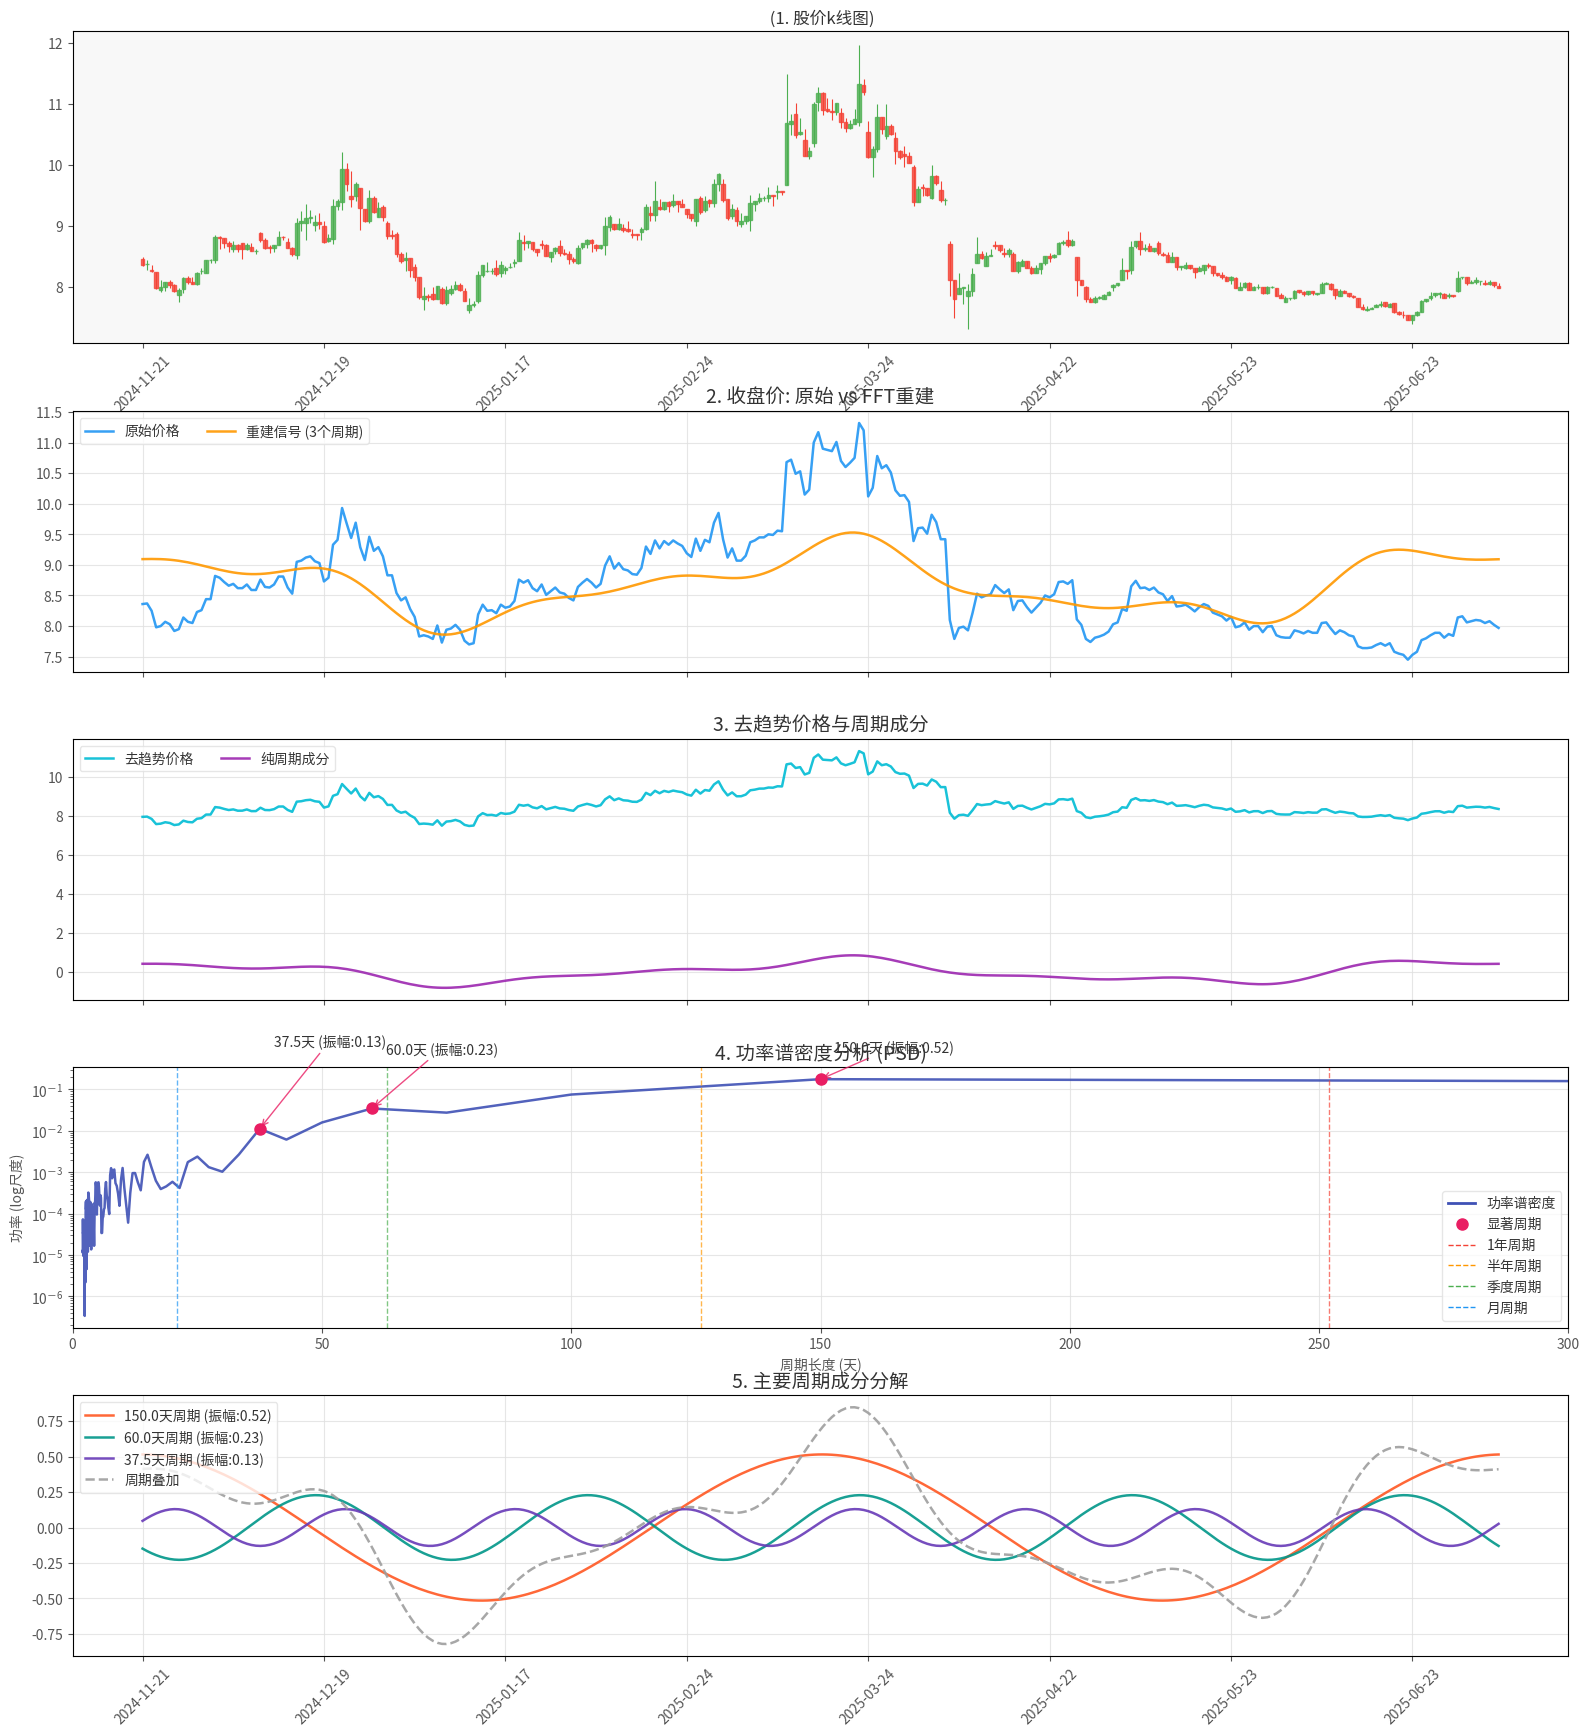


检测到显著周期:
1. 150.0天周期 (振幅:0.5152)
2. 60.0天周期 (振幅:0.2280)
3. 37.5天周期 (振幅:0.1298)


In [43]:
# 完整技术分析看盘程序 v1.0
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import gridspec
from scipy import signal
import argparse
import datetime
from numpy.lib.stride_tricks import sliding_window_view

matplotlib.rc("font",family='STIXGeneral')
matplotlib.rcParams['axes.unicode_minus'] = False
# -*- coding: utf-8 -*-
def analyze_price_with_fft(ohlc_data):
    """对股价进行FFT分析并可视化（白色淡雅主题）"""
    
    plt.rcParams['axes.unicode_minus'] = False
    # 使用收盘价进行分析
    prices = ohlc_data['close']
    #prices = ohlc_data['ma5'].fillna(0)
    n = len(prices)
    
    # 1. 数据预处理
    detrended = signal.detrend(prices, type='linear')  # 去趋势
    demeaned = detrended - np.mean(detrended)  # 去均值
    
    # 2. 应用窗函数减少频谱泄漏
    window = signal.windows.hann(n)
    windowed_signal = demeaned * window
    window_correction = n * np.sum(window**2)
    
    # 3. FFT计算
    fft_result = np.fft.rfft(windowed_signal)
    freqs = np.fft.rfftfreq(n, d=1)  # 日频数据
    
    # 4. 功率谱密度计算
    psd = np.abs(fft_result)**2 / window_correction
    
    # 5. 识别显著峰值
    peaks, properties = signal.find_peaks(psd[1:], prominence=np.quantile(psd[1:], 0.95))
    if len(peaks) > 0:
        significant_idx = peaks[np.argsort(properties['prominences'])[-min(5, len(peaks)):][::-1]] + 1
        significant_periods = 1 / freqs[significant_idx]
        significant_amplitudes = np.abs(fft_result[significant_idx]) * 2 / n
    else:
        significant_idx = np.array([], dtype=int)
        significant_periods = np.array([])
        significant_amplitudes = np.array([])
    
    # 6. 重建主要周期信号
    reconstructed = np.zeros(n)
    for idx in significant_idx:
        amp = np.abs(fft_result[idx]) * 2 / n
        phase = np.angle(fft_result[idx])
        reconstructed += amp * np.cos(2 * np.pi * freqs[idx] * np.arange(n) + phase)
    
    # 7. 创建可视化图表 - 白色淡雅主题
    plt.style.use('default')
    plt.rcParams['axes.facecolor'] = 'white'
    plt.rcParams['figure.facecolor'] = 'white'
    plt.rcParams['grid.color'] = '#e0e0e0'
    plt.rcParams['text.color'] = '#333333'
    plt.rcParams['axes.labelcolor'] = '#555555'
    plt.rcParams['xtick.color'] = '#555555'
    plt.rcParams['ytick.color'] = '#555555'
    matplotlib.rc("font",family='Noto Sans CJK JP')
    matplotlib.rcParams['axes.unicode_minus'] = False
    fig = plt.figure(figsize=(16, 18), facecolor='white')
    gs = gridspec.GridSpec(5, 1, height_ratios=[1.2, 1, 1, 1, 1])
    
    # 生成连续索引和日期
    x = np.arange(len(ohlc_data))
    date_labels = [d.strftime('%Y-%m-%d') for d in ohlc_data.index]
    
    # ========== 图1: 原始K线图 ==========
    ax0 = plt.subplot(gs[0])
    ax0.set_facecolor('#f8f8f8')
    ax0.set_title(f' (1. 股价k线图)', color='#333333')
    
    # 分离阳线和阴线 - 使用柔和的颜色
    up = ohlc_data[ohlc_data.close >= ohlc_data.open]
    down = ohlc_data[ohlc_data.close < ohlc_data.open]
    
    # 绘制K线 - 使用柔和的颜色
    for seg, color in zip([up, down], ['#4CAF50', '#F44336']):  # 柔和的绿色和红色
        if not seg.empty:
            seg_x = x[ohlc_data.index.isin(seg.index)]
            ax0.vlines(seg_x, seg.low, seg.high, color=color, lw=0.8)
            ax0.bar(seg_x, seg.close-seg.open, 0.8, seg.open, 
                   color=color, edgecolor=color, alpha=0.8)
    
    # 日期设置
    ax0.xaxis.set_major_formatter(lambda x, _: date_labels[int(x)] if 0<=x<len(ohlc_data) else '')
    ax0.xaxis.set_major_locator(plt.MaxNLocator(10))
    plt.setp(ax0.get_xticklabels(), rotation=45, color='#555555')
    
    # ========== 图2: 原始价格和重建信号 ==========
    ax1 = plt.subplot(gs[1], sharex=ax0)
    ax1.set_facecolor('white')
    ax1.set_title('2. 收盘价: 原始 vs FFT重建', color='#333333', fontsize=14)
    
    # 绘制原始价格和重建信号
    ax1.plot(x, prices, '#2196F3', lw=1.8, alpha=0.9, label='原始价格')  # 柔和的蓝色
    ax1.plot(x, reconstructed + np.mean(prices), '#FF9800', lw=1.8, 
             alpha=0.9, label=f'重建信号 ({len(significant_periods)}个周期)')  # 柔和的橙色
    
    ax1.legend(ncol=2, loc='upper left', facecolor='white', edgecolor='#e0e0e0')
    ax1.grid(True, color='#e0e0e0', ls='-', alpha=0.8)
    plt.setp(ax1.get_xticklabels(), visible=False)
    
    # ========== 图3: 去趋势价格和重建信号 ==========
    ax2 = plt.subplot(gs[2], sharex=ax0)
    ax2.set_facecolor('white')
    ax2.set_title('3. 去趋势价格与周期成分', color='#333333', fontsize=14)
    
    # 绘制去趋势价格和纯周期成分
    ax2.plot(x, detrended + np.mean(prices), '#00BCD4', lw=1.8, alpha=0.9, label='去趋势价格')  # 青色
    ax2.plot(x, reconstructed, '#9C27B0', lw=1.8, alpha=0.9, label='纯周期成分')  # 紫色
    
    ax2.legend(ncol=2, loc='upper left', facecolor='white', edgecolor='#e0e0e0')
    ax2.grid(True, color='#e0e0e0', ls='-', alpha=0.8)
    plt.setp(ax2.get_xticklabels(), visible=False)
    
    # ========== 图4: 功率谱密度 ==========
    ax3 = plt.subplot(gs[3])
    ax3.set_facecolor('white')
    ax3.set_title('4. 功率谱密度分析 (PSD)', color='#333333', fontsize=14)
    
    # 绘制功率谱密度
    ax3.semilogy(1/freqs[1:], psd[1:], '#3F51B5', lw=1.8, alpha=0.9, label='功率谱密度')  # 靛蓝色
    
    if len(significant_idx) > 0:
        ax3.semilogy(1/freqs[significant_idx], psd[significant_idx], 'o', 
                    color='#E91E63', markersize=8, label='显著周期')  # 粉红色标记
        
        # 添加周期标签
        for i, (period, amp) in enumerate(zip(significant_periods, significant_amplitudes)):
            ax3.annotate(f'{period:.1f}天 (振幅:{amp:.2f})', 
                         (period, psd[significant_idx[i]]),
                         xytext=(10, 20+20*i), textcoords='offset points',
                         fontsize=10, color='#333333',
                         arrowprops=dict(arrowstyle="->", color='#E91E63', alpha=0.8))
    
    # 添加常见金融周期参考线
    for period, color in [(252, '#F44336'), (126, '#FF9800'), (63, '#4CAF50'), (21, '#2196F3')]:
        ax3.axvline(period, color=color, ls='--', lw=1, alpha=0.7)
    
    # 添加图例
    handles = [
        plt.Line2D([0], [0], color='#3F51B5', lw=2, label='功率谱密度'),
        plt.Line2D([0], [0], marker='o', color='#E91E63', markersize=8, label='显著周期', linestyle='None'),
        plt.Line2D([0], [0], color='#F44336', ls='--', lw=1, label='1年周期'),
        plt.Line2D([0], [0], color='#FF9800', ls='--', lw=1, label='半年周期'),
        plt.Line2D([0], [0], color='#4CAF50', ls='--', lw=1, label='季度周期'),
        plt.Line2D([0], [0], color='#2196F3', ls='--', lw=1, label='月周期')
    ]
    ax3.legend(handles=handles, loc='best', facecolor='white', edgecolor='#e0e0e0')
    
    ax3.set_xlabel('周期长度 (天)', color='#555555')
    ax3.set_ylabel('功率 (log尺度)', color='#555555')
    ax3.grid(True, color='#e0e0e0', ls='-', alpha=0.8)
    ax3.set_xlim(0, 300)
    
    # ========== 图5: 主要周期分解 ==========
    ax4 = plt.subplot(gs[4], sharex=ax0)
    ax4.set_facecolor('white')
    ax4.set_title('5. 主要周期成分分解', color='#333333', fontsize=14)
    
    if len(significant_idx) > 0:
        cumulative = np.zeros(n)
        colors = ['#FF5722', '#009688', '#673AB7', '#E91E63', '#795548']  # 柔和的彩色
        
        for i, idx in enumerate(significant_idx):
            amp = np.abs(fft_result[idx]) * 2 / n
            phase = np.angle(fft_result[idx])
            cycle = amp * np.cos(2 * np.pi * freqs[idx] * np.arange(n) + phase)
            cumulative += cycle
            
            ax4.plot(x, cycle, color=colors[i % len(colors)], 
                     lw=1.8, alpha=0.9, 
                     label=f'{significant_periods[i]:.1f}天周期 (振幅:{amp:.2f})')
        
        ax4.plot(x, cumulative, '#9E9E9E', lw=1.8, alpha=0.9, label='周期叠加', ls='--')  # 灰色虚线
        ax4.legend(loc='upper left', facecolor='white', edgecolor='#e0e0e0')
    else:
        ax4.text(0.5, 0.5, '未检测到显著周期性模式', 
                horizontalalignment='center', verticalalignment='center',
                transform=ax4.transAxes, fontsize=12, color='#555555')
    
    ax4.grid(True, color='#e0e0e0', ls='-', alpha=0.8)
    
    # 设置日期标签
    plt.setp(ax4.get_xticklabels(), rotation=45, color='#555555')
    ax4.xaxis.set_major_formatter(lambda x, _: date_labels[int(x)] if 0<=x<len(ohlc_data) else '')
    ax4.xaxis.set_major_locator(plt.MaxNLocator(10))
    
    # 调整布局
    plt.tight_layout()
    plt.subplots_adjust(top=0.95, hspace=0.25)
    
    # 显示图表
    plt.show()
    
    # 打印检测结果
    if len(significant_periods) > 0:
        print("\n检测到显著周期:")
        for i, period in enumerate(significant_periods):
            print(f"{i+1}. {period:.1f}天周期 (振幅:{significant_amplitudes[i]:.4f})")
    else:
        print("\n未检测到显著周期性模式")
    
    # 返回结果
    return {
        'significant_periods': significant_periods,
        'amplitudes': significant_amplitudes,
        'reconstructed': reconstructed + np.mean(prices),
        'psd': psd,
        'frequencies': freqs
    }





    





    



    
# ================= 主程序 =================
if __name__ == "__main__":
    # MindGo数据获取（需在平台环境中运行）
    # 方法一：使用平台内置数据接口
    from mindgo_api import *
    # 创建命令行参数解析器
    parser = argparse.ArgumentParser(description='Get stock data by code.')
    parser.add_argument(
        '--code',                # 参数名
        type=str,
        default='300441.SZ',     # 默认证券代码
        help='Stock code (default: 300035.SZ)'
    )
    
    # 解析参数时忽略未知参数
    args, unknown = parser.parse_known_args()  # 关键修改
    df = get_price(
        securities=args.code,  # 注意参数名是复数但支持单个代码
        end_date=datetime.date.today().strftime('%Y%m%d'),  # 结束日期设为今天
        fre_step='120m',           # 日线频率
        fields=['open','high','low','close','volume'],
        fq='pre',                # 前复权
        bar_count=300,           # 获取250根K线
        skip_paused=True         # 跳过停牌日
    ).sort_index()  # 清除证券代码索引层级
    df['ma5'] = df['close'].rolling(window=5).mean()
    # 检查数据样例
    print(f"最新数据日期：{df.index[-1].strftime('%Y-%m-%d')}")
    print(df.tail())
    # 使用您的数据调用分析函数
    results = analyze_price_with_fft(df)